# 05 — 2D Segmentation with SAM3

In this notebook, similar to the previous one, we will focus on the segmentation stage of the pipeline, but this time we will evaluate the performance of **SAM3** for segmenting and tracking parts of a subject across the video frames.

### In this notebook, we will:

1. **RGB stream sanity check**
   - Load the `.vrs` file with `projectaria_tools`.
   - Validate RGB stream access and timestamp consistency.

2. **Frames conversion to 5fps and prompt initialization**
   - Downsample the original 30fps frames to 5fps for efficient SAM3 inference.
   - Select only a few clean frames to initialize prompts.

3. **SAM3 baseline segmentation**
   - Multi-object prompting (beard and hands).
   - Mask propagation across time.

4. **Failure analysis and diagnostics**
   - Inspect drift, mask merging, holes, and missing thin parts.
   - Produce visual overlays for qualitative review.

5. **Quantitative temporal metrics**
   - Mask area stability, centroid jitter, continuity/drop rate.

As a sample, we will use `gnome_bright.vrs` located in the local `data/raw/gnome_bright/` directory.

For this notebook, we used as references:
* SAM3: https://github.com/facebookresearch/sam3

## 5.1 RGB Stream Sanity Check

In this section, we validate RGB stream access, timestamps, and frame decoding for `gnome_bright.vrs`. 

In [1]:
import os
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
from projectaria_tools.core import data_provider, sensor_data

In [2]:
# Paths and basic validation
VRS_PATH = os.path.join("..", "data", "raw", "gnome_bright", "gnome_bright.vrs")
OUT_ROOT = os.path.join("..", "data", "outputs", "segmentation", "gnome")
Path(OUT_ROOT).mkdir(parents=True, exist_ok=True)

if not os.path.exists(VRS_PATH):
    raise FileNotFoundError(f"VRS file not found: {os.path.abspath(VRS_PATH)}")

print("VRS path:", os.path.abspath(VRS_PATH))
print("Output root:", os.path.abspath(OUT_ROOT))

# Make project helpers importable
cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]
project_root = next((p for p in candidates if (p / "scripts" / "aria_dataset.py").exists()), None)
if project_root is None:
    raise RuntimeError(f"Cannot find scripts/aria_dataset.py from cwd={cwd}")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from scripts.aria_dataset import _extract_image_array_from_sample

VRS path: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\raw\gnome_bright\gnome_bright.vrs
Output root: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\segmentation\gnome


In [3]:
# Helper functions for VRS access and RGB stream handling
def create_provider(vrs_path: str):
    provider = data_provider.create_vrs_data_provider(vrs_path)
    if provider is None:
        raise RuntimeError("Failed to create VRS data provider.")
    return provider

# Attempt to find the RGB stream by preferred ID, then by label heuristics
def resolve_rgb_stream(provider, preferred_stream_id_str: str = "214-1"):
    candidates = [sid for sid in provider.get_all_streams() if str(sid) == preferred_stream_id_str]
    if len(candidates) > 0:
        stream_id = candidates[0]
        return provider.get_label_from_stream_id(stream_id), stream_id, provider.get_num_data(stream_id)

    for stream_id in provider.get_all_streams():
        label = str(provider.get_label_from_stream_id(stream_id)).lower()
        if "rgb" in label:
            return provider.get_label_from_stream_id(stream_id), stream_id, provider.get_num_data(stream_id)

    raise RuntimeError("No RGB stream found in VRS.")

# Retrieve RGB timestamps in nanoseconds for a given stream and sample count
def get_rgb_timestamps_ns(provider, stream_id, sample_count):
    timestamps = np.empty(sample_count, dtype=np.int64)
    for i in range(sample_count):
        sample = provider.get_sensor_data_by_index(stream_id, i)
        timestamps[i] = sample.get_time_ns(sensor_data.TimeDomain.DEVICE_TIME)
    return timestamps

# Retrieve RGB frame as a numpy array for a given stream and sample index
def get_rgb_frame_by_index(provider, stream_id, index: int):
    sample = provider.get_sensor_data_by_index(stream_id, int(index))
    return _extract_image_array_from_sample(sample)

RGB stream label: camera-rgb
RGB stream id: 214-1
RGB sample count: 4028
Duration: 134.21 s


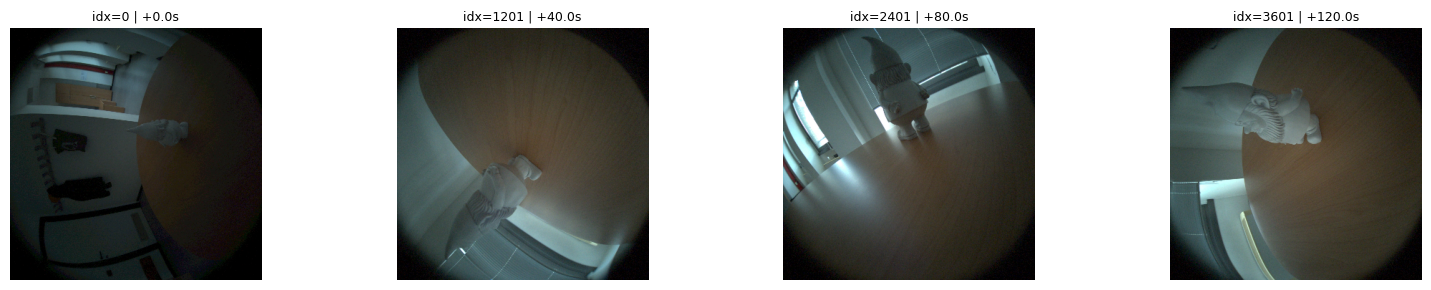

In [4]:
provider = create_provider(VRS_PATH)
rgb_label, rgb_stream_id, rgb_sample_count = resolve_rgb_stream(provider)
rgb_timestamps_ns = get_rgb_timestamps_ns(provider, rgb_stream_id, rgb_sample_count)

print("RGB stream label:", rgb_label)
print("RGB stream id:", rgb_stream_id)
print("RGB sample count:", rgb_sample_count)

base_ts_ns = int(rgb_timestamps_ns[0])
last_ts_ns = int(rgb_timestamps_ns[-1])
duration_s = (last_ts_ns - base_ts_ns) / 1e9
print(f"Duration: {duration_s:.2f} s")

# Display one frame every 40 seconds as a sanity check
step_s = 40
target_offsets_s = list(range(0, int(duration_s) + 1, step_s))

sample_indices = []
for off_s in target_offsets_s:
    target_ts_ns = base_ts_ns + int(off_s * 1e9)
    idx = int(np.searchsorted(rgb_timestamps_ns, target_ts_ns, side="left"))
    if idx >= rgb_sample_count:
        idx = rgb_sample_count - 1
    sample_indices.append(idx)

# Deduplicate while preserving order
seen = set()
sample_indices = [i for i in sample_indices if not (i in seen or seen.add(i))]

downsample = 4
ncols = 4
nrows = (len(sample_indices) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = np.array(axes).reshape(nrows, ncols)

for k in range(nrows * ncols):
    ax = axes.flat[k]
    ax.axis("off")
    if k >= len(sample_indices):
        continue

    idx = sample_indices[k]
    frame_rgb = get_rgb_frame_by_index(provider, rgb_stream_id, idx)
    frame_small = frame_rgb[::downsample, ::downsample]
    rel_s = (int(rgb_timestamps_ns[idx]) - base_ts_ns) / 1e9

    ax.imshow(frame_small)
    ax.set_title(f"idx={idx} | +{rel_s:.1f}s", fontsize=9)

plt.tight_layout()
plt.show()

## 5.2 Frames Conversion to 5fps and Prompt Initialization

In this section, we convert the original 30fps frames to 5fps for efficient SAM3 inference.

We also inspect a few candidate frames and choose a clean prompt frame for the initial segmentation.

In [5]:
import shutil
from PIL import Image
import matplotlib.patches as patches

# Output directories
SAM3_ROOT = Path(OUT_ROOT) / "sam3"
SAM3_FRAMES_DIR = SAM3_ROOT / "frames"
SAM3_FRAMES_DIR_5FPS = SAM3_ROOT / "frames_5fps"

SAM3_FRAMES_DIR.mkdir(parents=True, exist_ok=True)
SAM3_FRAMES_DIR_5FPS.mkdir(parents=True, exist_ok=True)

print("SAM3 root:", SAM3_ROOT)
print("Frames dir:", SAM3_FRAMES_DIR)
print("5fps frames dir:", SAM3_FRAMES_DIR_5FPS)

SAM3 root: ..\data\outputs\segmentation\gnome\sam3
Frames dir: ..\data\outputs\segmentation\gnome\sam3\frames
5fps frames dir: ..\data\outputs\segmentation\gnome\sam3\frames_5fps


In [6]:
# 5.2.1 Exports RGB frames to disk with caching and optional force rebuild
def export_rgb_frames(
    provider,
    stream_id,
    sample_count: int,
    out_dir: Path,
    ext: str = "jpg",
    jpg_quality: int = 95,
    force_rebuild: bool = False,
):
    out_dir.mkdir(parents=True, exist_ok=True)
    ext = ext.lower().lstrip(".")

    expected_files = [out_dir / f"{i:06d}.{ext}" for i in range(sample_count)]
    cache_complete = all(p.exists() for p in expected_files)

    if cache_complete and not force_rebuild:
        print(f"Frame cache already complete. Skipping export: {out_dir}")
        return

    if force_rebuild:
        for p in out_dir.glob(f"*.{ext}"):
            p.unlink()

    for i in range(sample_count):
        out_path = out_dir / f"{i:06d}.{ext}"
        if out_path.exists() and not force_rebuild:
            continue

        frame_rgb = get_rgb_frame_by_index(provider, stream_id, i)
        Image.fromarray(frame_rgb).save(out_path, quality=jpg_quality, subsampling=0, optimize=True)

    print(f"Export completed: {out_dir} ({sample_count} frames, .{ext})")

In [7]:
# 5.2.2 Export full 30fps RGB sequence to disk
export_rgb_frames(
    provider=provider,
    stream_id=rgb_stream_id,
    sample_count=rgb_sample_count,
    out_dir=SAM3_FRAMES_DIR,
    ext="jpg",
    jpg_quality=95,
    force_rebuild=False,
)

Frame cache already complete. Skipping export: ..\data\outputs\segmentation\gnome\sam3\frames


In [8]:
# 5.2.3 Convert exported frames to 5fps with caching and optional force rebuild
def convert_frames_to_5fps(
    frames_dir: Path,
    out_dir: Path,
    original_fps: int = 30,
    target_fps: int = 5,
    ext: str = "jpg",
    force_rebuild: bool = False,
):
    out_dir.mkdir(parents=True, exist_ok=True)
    ext = ext.lower().lstrip(".")

    frame_files = sorted(frames_dir.glob(f"*.{ext}"))
    if len(frame_files) == 0:
        raise RuntimeError(f"No frames found in {frames_dir} with extension .{ext}")

    step = int(round(original_fps / target_fps))
    if step <= 0:
        raise ValueError("Invalid fps ratio")

    selected_files = frame_files[::step]

    expected_files = [out_dir / f"{i:06d}.{ext}" for i in range(len(selected_files))]
    cache_complete = all(p.exists() for p in expected_files)

    if cache_complete and not force_rebuild:
        print(f"5fps cache already complete. Skipping conversion: {out_dir}")
        print(f"Frames already available: {len(selected_files)}")
        return

    if force_rebuild:
        for p in out_dir.glob(f"*.{ext}"):
            p.unlink()

    for i, src_path in enumerate(selected_files):
        dst_path = out_dir / f"{i:06d}.{ext}"
        if dst_path.exists() and not force_rebuild:
            continue
        shutil.copy2(src_path, dst_path)

    print(f"Converted {len(frame_files)} -> {len(selected_files)} frames in {out_dir}")

In [9]:
convert_frames_to_5fps(
    frames_dir=SAM3_FRAMES_DIR,
    out_dir=SAM3_FRAMES_DIR_5FPS,
    original_fps=30,
    target_fps=5,
    ext="jpg",
    force_rebuild=False,
)

5fps cache already complete. Skipping conversion: ..\data\outputs\segmentation\gnome\sam3\frames_5fps
Frames already available: 672


### 5.2.4 Prompt Initialization

We use fixed prompt frames (already in the 5fps timeline):
- Frame 120: hat and eyes
- Frame 425: right hand

No 30fps-to-5fps index conversion is needed for these prompts as it was already done.

In [26]:
# Fixed prompt frames in the 5fps timeline (no conversion needed)
frame_files_5fps = sorted(SAM3_FRAMES_DIR_5FPS.glob("*.jpg"))
if len(frame_files_5fps) == 0:
    raise RuntimeError(f"No JPG frames found in: {SAM3_FRAMES_DIR_5FPS}")

PROMPT_FRAME_IDX_BY_OBJECT = {
    "beard": 120,
    "hat": 120,
    "hand": 425,
}

# Validate indices
max_idx = len(frame_files_5fps) - 1
for obj_name, idx in PROMPT_FRAME_IDX_BY_OBJECT.items():
    if idx < 0 or idx > max_idx:
        raise ValueError(
            f"Prompt index out of range for {obj_name}: {idx} (valid: 0..{max_idx})"
        )

print("5fps frame count:", len(frame_files_5fps))
print("Prompt frames:", PROMPT_FRAME_IDX_BY_OBJECT)

5fps frame count: 672
Prompt frames: {'beard': 120, 'hat': 120, 'hand': 425}


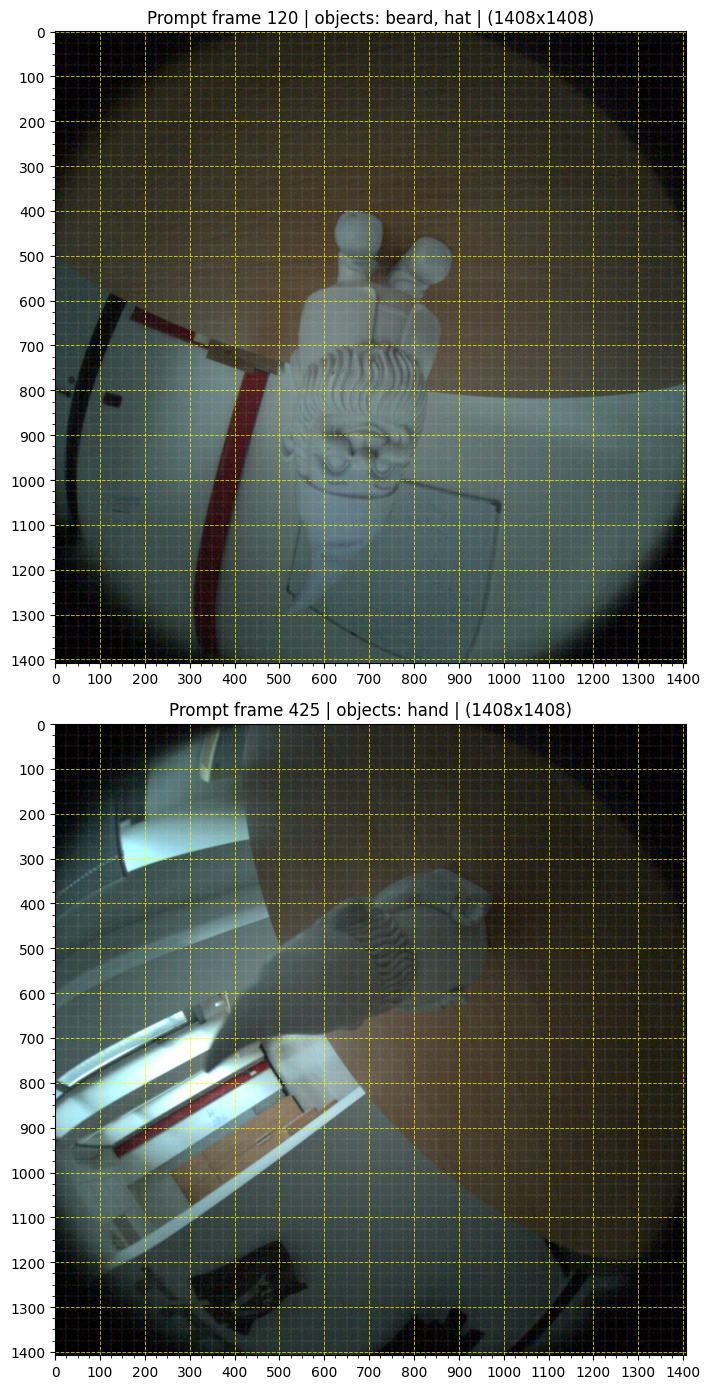

In [27]:
# Detailed visual check of fixed prompt frames (full view only, dense grid)
fixed_prompt_frames = sorted(set(PROMPT_FRAME_IDX_BY_OBJECT.values()))

nrows = len(fixed_prompt_frames)
ncols = 1

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 7 * nrows))
if nrows == 1:
    axes = [axes]

for r, idx in enumerate(fixed_prompt_frames):
    frame_rgb = np.array(Image.open(frame_files_5fps[idx]).convert("RGB"))
    h, w = frame_rgb.shape[:2]

    objs_here = [name for name, fidx in PROMPT_FRAME_IDX_BY_OBJECT.items() if fidx == idx]
    title_base = f"Prompt frame {idx} | objects: {', '.join(objs_here)} | ({w}x{h})"

    ax = axes[r]
    ax.imshow(frame_rgb)
    ax.set_title(title_base, fontsize=12)
    ax.axis("on")

    # Major grid every 100 px
    ax.set_xticks(np.arange(0, w + 1, 100))
    ax.set_yticks(np.arange(0, h + 1, 100))

    # Minor grid every 25 px
    ax.set_xticks(np.arange(0, w + 1, 25), minor=True)
    ax.set_yticks(np.arange(0, h + 1, 25), minor=True)

    ax.grid(which="major", color="yellow", linestyle="--", linewidth=0.7, alpha=0.7)
    ax.grid(which="minor", color="white", linestyle=":", linewidth=0.35, alpha=0.45)

plt.tight_layout()
plt.show()

In [28]:
# Prompt boxes in 5fps coordinates: [x0, y0, x1, y1]
BOX_PROMPTS_5FPS = {
    "beard": [525, 675, 825, 900],
    "hat": [500, 975, 750, 1300],
    "hand": [875, 375, 990, 450],
}

# Object IDs used later during SAM3 prompting
OBJECT_IDS = {
    "beard": 1,
    "hat": 2,
    "hand": 3,
}

print("BOX_PROMPTS_5FPS:", BOX_PROMPTS_5FPS)
print("OBJECT_IDS:", OBJECT_IDS)

BOX_PROMPTS_5FPS: {'beard': [525, 675, 825, 900], 'hat': [500, 975, 750, 1300], 'hand': [875, 375, 990, 450]}
OBJECT_IDS: {'beard': 1, 'hat': 2, 'hand': 3}


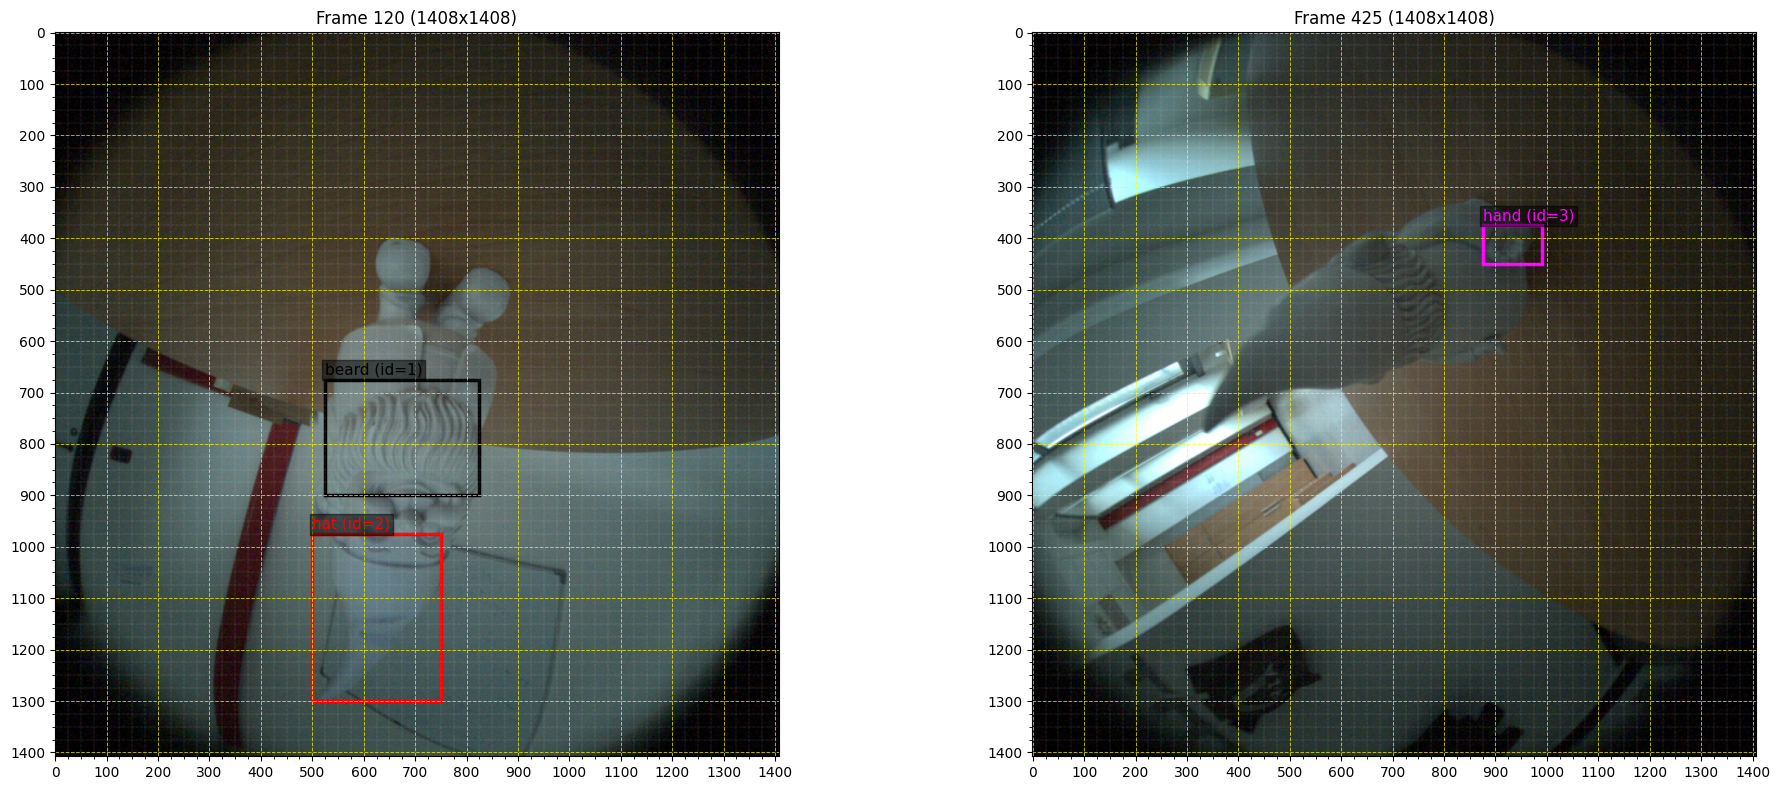

In [29]:
# Visual verification of prompt boxes on their assigned frames
import matplotlib.patches as patches

colors = {
    "beard": "black",
    "hat": "red",
    "hand": "magenta",
}

fixed_prompt_frames = sorted(set(PROMPT_FRAME_IDX_BY_OBJECT.values()))
fig, axes = plt.subplots(1, len(fixed_prompt_frames), figsize=(10 * len(fixed_prompt_frames), 8))
if len(fixed_prompt_frames) == 1:
    axes = [axes]

for ax, frame_idx in zip(axes, fixed_prompt_frames):
    frame_rgb = np.array(Image.open(frame_files_5fps[frame_idx]).convert("RGB"))
    h, w = frame_rgb.shape[:2]

    ax.imshow(frame_rgb)
    ax.set_title(f"Frame {frame_idx} ({w}x{h})")
    ax.axis("on")

    # dense grid for precise inspection
    ax.set_xticks(np.arange(0, w + 1, 100))
    ax.set_yticks(np.arange(0, h + 1, 100))
    ax.set_xticks(np.arange(0, w + 1, 25), minor=True)
    ax.set_yticks(np.arange(0, h + 1, 25), minor=True)
    ax.grid(which="major", color="yellow", linestyle="--", linewidth=0.7, alpha=0.7)
    ax.grid(which="minor", color="white", linestyle=":", linewidth=0.35, alpha=0.45)

    # draw objects assigned to this frame
    objs_here = [name for name, idx in PROMPT_FRAME_IDX_BY_OBJECT.items() if idx == frame_idx]
    for obj_name in objs_here:
        x0, y0, x1, y1 = BOX_PROMPTS_5FPS[obj_name]
        rect = patches.Rectangle(
            (x0, y0),
            x1 - x0,
            y1 - y0,
            fill=False,
            linewidth=2.5,
            edgecolor=colors.get(obj_name, "lime"),
        )
        ax.add_patch(rect)
        ax.text(
            x0,
            max(0, y0 - 10),
            f"{obj_name} (id={OBJECT_IDS[obj_name]})",
            color=colors.get(obj_name, "lime"),
            fontsize=11,
            bbox=dict(facecolor="black", alpha=0.5, pad=2),
        )

plt.tight_layout()
plt.show()

## 5.3 SAM3 Baseline Segmentation

In this section, we initialize SAM3 on the 5fps frame folder, add box prompts on fixed frames, and propagate masks across the sequence.
We will use the Small SAM3 model for the evaluation.

In [14]:
# 5.3.1 Runtime setup
import torch
from PIL import Image

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE != "cuda":
    raise RuntimeError("CUDA is required for this SAM3 run.")

SAM3_MASKS_DIR = SAM3_ROOT / "masks"
SAM3_VIS_DIR = SAM3_ROOT / "visualizations"
SAM3_MASKS_DIR.mkdir(parents=True, exist_ok=True)
SAM3_VIS_DIR.mkdir(parents=True, exist_ok=True)

SAVE_OVERLAYS = False
SAVE_EVERY_N = 1
OVERLAY_EVERY_N = 50
CLEAN_PREVIOUS_OUTPUTS = False

if CLEAN_PREVIOUS_OUTPUTS:
    for p in SAM3_MASKS_DIR.glob("*.png"):
        p.unlink()
    for p in SAM3_VIS_DIR.glob("*.jpg"):
        p.unlink()

print("DEVICE:", DEVICE)
print("Frames (5fps):", SAM3_FRAMES_DIR_5FPS)
print("Masks dir:", SAM3_MASKS_DIR)
print("Vis dir:", SAM3_VIS_DIR)

DEVICE: cuda
Frames (5fps): ..\data\outputs\segmentation\gnome\sam3\frames_5fps
Masks dir: ..\data\outputs\segmentation\gnome\sam3\masks
Vis dir: ..\data\outputs\segmentation\gnome\sam3\visualizations


### 5.3.2 GPU Cache Cleanup (Before Model Init)

This cell clears Python and CUDA caches before building the predictor.

In [15]:
# Ensure no lingering references to SAM3 state or predictor that could hold GPU memory
for v in ["inference_state"]:
    if v in globals():
        del globals()[v]
import gc, torch
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [16]:
import gc
import torch

gc.collect()

if torch.cuda.is_available():
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    torch.cuda.reset_peak_memory_stats()
    print(
        "CUDA cache cleared | allocated:",
        f"{torch.cuda.memory_allocated() / (1024**3):.3f} GB | reserved:",
        f"{torch.cuda.memory_reserved() / (1024**3):.3f} GB"
    )
else:
    print("CUDA not available.")

CUDA cache cleared | allocated: 0.000 GB | reserved: 0.000 GB


In [17]:
from pathlib import Path
import sys

# Trova root progetto
cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]
project_root = next((p for p in candidates if (p / "third_party" / "sam3").exists()), None)
if project_root is None:
    raise RuntimeError(f"Non trovo third_party/sam3 da cwd={cwd}")

sam3_repo = project_root / "third_party" / "sam3"
if str(sam3_repo) not in sys.path:
    sys.path.insert(0, str(sam3_repo))

# Cerca checkpoint SAM3 small
ckpt_candidates = [
    project_root / "checkpoints" / "sam3_hiera_small.pt",
    sam3_repo / "checkpoints" / "sam3_hiera_small.pt",
]
checkpoint_path = next((p for p in ckpt_candidates if p.exists()), None)

if checkpoint_path is None:
    found = []
    for d in [project_root / "checkpoints", sam3_repo / "checkpoints"]:
        if d.exists():
            found.extend([str(p) for p in d.glob("*.pt")])
    raise FileNotFoundError("Checkpoint SAM3 non trovato. Trovati: " + str(found))

print("checkpoint_path =", checkpoint_path)

checkpoint_path = C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\checkpoints\sam3_hiera_small.pt


In [18]:
from pathlib import Path
import sys

# trova root progetto
cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]
project_root = next((p for p in candidates if (p / "third_party" / "sam3").exists()), None)
if project_root is None:
    raise RuntimeError(f"Cannot find third_party/sam3 from cwd={cwd}")

sam3_repo = project_root / "third_party" / "sam3"
if str(sam3_repo) not in sys.path:
    sys.path.insert(0, str(sam3_repo))

from sam3.model_builder import build_sam3_predictor
print("Import OK:", build_sam3_predictor)

Import OK: <function build_sam3_predictor at 0x000001F36C0B6E80>


c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [19]:
predictor = build_sam3_predictor(
    version="sam3",
    compile=False,
    async_loading_frames=True,
)
print(type(predictor).__name__)

INFO 2026-04-08 23:07:26,411 26216 sam3_video_predictor.py: 109: using the following GPU IDs: [0]
INFO 2026-04-08 23:07:26,412 26216 sam3_video_predictor.py: 125: 


	*** START loading model on all ranks ***


INFO 2026-04-08 23:07:26,413 26216 sam3_video_predictor.py: 127: loading model on rank=0 with world_size=1 -- this could take a while ...
INFO 2026-04-08 23:07:34,814 26216 sam3_video_base.py: 348: setting max_num_objects=10000 and num_obj_for_compile=16
INFO 2026-04-08 23:07:57,968 26216 sam3_video_predictor.py: 129: loading model on rank=0 with world_size=1 -- DONE locally
INFO 2026-04-08 23:07:57,969 26216 sam3_video_predictor.py: 140: 


	*** DONE loading model on all ranks ***




Sam3VideoPredictorMultiGPU


### 5.3.3 Segmentation Run
We will now start the segmentation on the 5fps frames: adds normalized box prompts for each object, propagates masks forward, and saves per-object masks as PNG files.

### 5.3.3.a Modular Segmentation Blocks

The segmentation pipeline is split into reusable blocks:
1. Run configuration
2. Utility helpers
3. Single-object tracker
4. Full-run orchestrator

These cells are definition-only and can be executed when needed.

In [ ]:
import gc
import numpy as np
import torch
from PIL import Image

# Segmentation run configuration
SEGMENTATION_CONFIG = {
    "save_overlays": True,
    "overlay_alpha": 0.40,
    "clean_previous_outputs": True,
    "track_internal_step": 1,
    "dilation_pixels_on_retry": 28,
    "carry_mask_max_gap": 2,
    "enforce_min_mask_area": False,
    "strict_object_id_match": True,
    "allow_single_key_strict_fallback": True,
    "prompt_output_prob_thresh": -1.0,
}

MIN_MASK_AREA_BY_OBJECT = {
    "beard": 1200,
    "hat": 1500,
    "hand": 200,
}

RUN_OBJECTS = ["beard", "hat", "hand"]
FILE_NAME_BY_OBJECT = {"beard": "beard", "hat": "hat", "hand": "hand"}
ANCHOR_BY_OBJECT = {"beard": 120, "hat": 120, "hand": 425}

if SEGMENTATION_CONFIG["clean_previous_outputs"]:
    for p in SAM3_MASKS_DIR.glob("*.png"):
        p.unlink()
    for p in SAM3_VIS_DIR.glob("*.jpg"):
        p.unlink()

SAM3_MASKS_DIR.mkdir(parents=True, exist_ok=True)
SAM3_VIS_DIR.mkdir(parents=True, exist_ok=True)

if len(frame_files_5fps) == 0:
    raise RuntimeError("No 5fps frames found.")
if SEGMENTATION_CONFIG["track_internal_step"] <= 0:
    raise ValueError("track_internal_step must be > 0")

NUM_FRAMES = len(frame_files_5fps)
FIRST_FRAME = np.array(Image.open(frame_files_5fps[0]).convert("RGB"))
FRAME_H, FRAME_W = FIRST_FRAME.shape[:2]
EMPTY_MASK = np.zeros((FRAME_H, FRAME_W), dtype=bool)

COLOR_BY_OBJ = {
    int(OBJECT_IDS["beard"]): [0, 0, 0],
    int(OBJECT_IDS["hat"]): [255, 0, 0],
    int(OBJECT_IDS["hand"]): [255, 0, 255],
}

COMBINED_MASKS_BY_FRAME = {i: {} for i in range(NUM_FRAMES)}

In [ ]:
def _to_numpy(mask_data):
    if mask_data is None:
        return np.zeros((0,), dtype=bool)
    if hasattr(mask_data, "detach"):
        mask_data = mask_data.detach().cpu().numpy()
    else:
        mask_data = np.asarray(mask_data)
    return mask_data


def _extract_mask_candidates(mask_data):
    mask_data = _to_numpy(mask_data)
    if mask_data.size == 0:
        return []
    if mask_data.ndim == 2:
        return [mask_data.astype(bool)]
    if mask_data.ndim == 3:
        if mask_data.shape[0] == 1:
            return [mask_data[0].astype(bool)]
        return [m.astype(bool) for m in mask_data]
    if mask_data.ndim == 4:
        if mask_data.shape[1] == 1:
            mask_data = mask_data[:, 0]
            return [m.astype(bool) for m in mask_data]
        if mask_data.shape[0] == 1:
            mask_data = mask_data[0]
            if mask_data.ndim == 3:
                return [m.astype(bool) for m in mask_data]
    return []


def _pick_primary_mask(mask_data):
    candidates = _extract_mask_candidates(mask_data)
    if len(candidates) == 0:
        return None
    areas = [int(mask.sum()) for mask in candidates]
    best_idx = int(np.argmax(areas))
    best_mask = candidates[best_idx].astype(bool)
    return best_mask if best_mask.any() else None


def _find_matching_key(obj_map, preferred_obj_id):
    target = int(preferred_obj_id)
    for k in obj_map.keys():
        try:
            if int(k) == target:
                return k
        except Exception:
            continue
    return None


def _pick_mask_from_obj_map(obj_id_to_mask, preferred_obj_id, strict_match=True, allow_single_fallback=True):
    if obj_id_to_mask is None or len(obj_id_to_mask) == 0:
        return None, []

    keys = list(obj_id_to_mask.keys())
    matched_key = _find_matching_key(obj_id_to_mask, preferred_obj_id)

    if strict_match:
        if matched_key is not None:
            return _pick_primary_mask(obj_id_to_mask[matched_key]), keys
        if allow_single_fallback and len(keys) == 1:
            return _pick_primary_mask(obj_id_to_mask[keys[0]]), keys
        return None, keys

    if matched_key is not None:
        return _pick_primary_mask(obj_id_to_mask[matched_key]), keys

    best_mask = None
    best_area = -1
    for _, v in obj_id_to_mask.items():
        m = _pick_primary_mask(v)
        if m is None:
            continue
        area = int(m.sum())
        if area > best_area:
            best_area = area
            best_mask = m
    return best_mask, keys


def _normalize_xywh_topleft(box_xyxy, width, height):
    x0, y0, x1, y1 = box_xyxy
    return [
        float(x0) / float(width),
        float(y0) / float(height),
        float(x1 - x0) / float(width),
        float(y1 - y0) / float(height),
    ]


def _mask_to_box_xyxy(mask_bool):
    ys, xs = np.where(mask_bool)
    if ys.size == 0 or xs.size == 0:
        return None
    x0 = int(xs.min())
    x1 = int(xs.max()) + 1
    y0 = int(ys.min())
    y1 = int(ys.max()) + 1
    return [x0, y0, x1, y1]


def _expand_box_xyxy(box_xyxy, pad, w, h):
    x0, y0, x1, y1 = box_xyxy
    x0 = max(0, x0 - pad)
    y0 = max(0, y0 - pad)
    x1 = min(w, x1 + pad)
    y1 = min(h, y1 + pad)
    return [int(x0), int(y0), int(x1), int(y1)]


def _extract_outputs(wrapper):
    if isinstance(wrapper, dict) and "outputs" in wrapper:
        return wrapper["outputs"]
    return wrapper if isinstance(wrapper, dict) else {}


def _save_object_mask(frame_idx, obj_name, mask_bool):
    tag = FILE_NAME_BY_OBJECT.get(obj_name, obj_name)
    mask_path = SAM3_MASKS_DIR / f"{frame_idx:06d}_{tag}.png"
    Image.fromarray((mask_bool.astype(np.uint8) * 255)).save(mask_path)
    return mask_path


def _register_mask(frame_idx, obj_id, mask_bool):
    COMBINED_MASKS_BY_FRAME[int(frame_idx)][int(obj_id)] = mask_bool


def _alpha_blend_overlay(rgb, frame_obj_masks, color_map, alpha=0.4):
    out = rgb.astype(np.float32).copy()
    for obj_id, mask in frame_obj_masks.items():
        if not np.any(mask):
            continue
        color = np.array(color_map.get(int(obj_id), [0, 255, 0]), dtype=np.float32)
        out[mask] = (1.0 - alpha) * out[mask] + alpha * color
    return np.clip(out, 0, 255).astype(np.uint8)


def _iter_direction_frames(anchor_idx, direction, total_frames, step):
    if direction == "forward":
        return list(range(anchor_idx + step, total_frames, step))
    if direction == "backward":
        return list(range(anchor_idx - step, -1, -step))
    raise ValueError(f"Unsupported direction: {direction}")

In [ ]:
# run inference on a single frame using an anchor prompt, with optional retries and fallbacks
def _run_frame_from_anchor(
    predictor_obj,
    model,
    session_state,
    session_id,
    obj_id,
    anchor_frame,
    anchor_box_norm,
    frame_idx,
    reverse,
    prob_thresh,
    preferred_obj_id,
    area_floor,
    label,
    log_prefix,
    verbose=False,
    predictor_ref=None,
    prompt_ref=None,
    box_pad=0,
    fallback_to_prompt=False,
    frame_w_local=None,
    frame_h_local=None,
    debug_every=50,
    prompt_frame_ref=None,
    is_terminal=False,
):
    run_box = anchor_box_norm
    if box_pad > 0 and predictor_ref is not None:
        box_xyxy = _mask_to_box_xyxy(predictor_ref)
        if box_xyxy is not None:
            box_xyxy = _expand_box_xyxy(box_xyxy, box_pad, frame_w_local, frame_h_local)
            run_box = _normalize_xywh_topleft(box_xyxy, frame_w_local, frame_h_local)

    run_anchor_frame = anchor_frame
    if fallback_to_prompt and prompt_ref is not None and prompt_frame_ref is not None:
        run_box = prompt_ref
        run_anchor_frame = int(prompt_frame_ref)

    predictor_obj.add_prompt(
        session_id=session_id,
        frame_idx=int(run_anchor_frame),
        bounding_boxes=[run_box],
        bounding_box_labels=[1],
        obj_id=obj_id,
        output_prob_thresh=prob_thresh,
    )

    with torch.inference_mode():
        raw_out = model._run_single_frame_inference(
            session_state,
            int(frame_idx),
            reverse=reverse,
        )

    obj_id_to_mask = raw_out.get("obj_id_to_mask", {}) if isinstance(raw_out, dict) else {}
    latest_mask, latest_keys = _pick_mask_from_obj_map(
        obj_id_to_mask,
        preferred_obj_id,
        strict_match=SEGMENTATION_CONFIG["strict_object_id_match"],
        allow_single_fallback=SEGMENTATION_CONFIG["allow_single_key_strict_fallback"],
    )

    is_valid = False
    area_val = 0
    if latest_mask is not None and np.any(latest_mask):
        area_val = int(latest_mask.sum())
        if SEGMENTATION_CONFIG["enforce_min_mask_area"]:
            is_valid = area_val >= area_floor
        else:
            is_valid = True

    if verbose and (int(frame_idx) % debug_every == 0 or is_terminal):
        print(
            f"{log_prefix} frame={int(frame_idx)} try={label} raw_obj_ids={latest_keys} "
            f"valid={is_valid} area={area_val}"
        )

    return latest_mask, latest_keys, is_valid

# Main tracking loop for a single object across the video, starting from its prompt frame and box
def _track_single_object(obj_name):
    object_id = int(OBJECT_IDS[obj_name])
    prompt_frame_idx = int(ANCHOR_BY_OBJECT[obj_name])
    area_floor = int(MIN_MASK_AREA_BY_OBJECT.get(obj_name, 1))

    if prompt_frame_idx < 0 or prompt_frame_idx >= NUM_FRAMES:
        raise ValueError(f"Invalid anchor {prompt_frame_idx} for {obj_name}")

    base_box_norm = _normalize_xywh_topleft(BOX_PROMPTS_5FPS[obj_name], FRAME_W, FRAME_H)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

    session = predictor.start_session(
        resource_path=str(SAM3_FRAMES_DIR_5FPS),
        offload_video_to_cpu=True,
    )
    session_id = session.get("session_id") if isinstance(session, dict) else session

    print(f"\n[{obj_name}] session_id={session_id} anchor={prompt_frame_idx} area_floor={area_floor}")

    metrics = {"steps": 0, "retries": 0, "saved_real": 0, "saved_empty": 0}

    try:
        prompt_out = predictor.add_prompt(
            session_id=session_id,
            frame_idx=prompt_frame_idx,
            bounding_boxes=[base_box_norm],
            bounding_box_labels=[1],
            obj_id=object_id,
            output_prob_thresh=SEGMENTATION_CONFIG["prompt_output_prob_thresh"],
        )

        prompt_outputs = _extract_outputs(prompt_out)
        prompt_mask = _pick_primary_mask(prompt_outputs.get("out_binary_masks", []))
        if prompt_mask is None:
            raise RuntimeError(f"[{obj_name}] prompt mask is empty at frame {prompt_frame_idx}")

        _register_mask(prompt_frame_idx, object_id, prompt_mask)
        _save_object_mask(prompt_frame_idx, obj_name, prompt_mask)
        metrics["saved_real"] += 1

        session_state = predictor._all_inference_states[session_id]["state"]
        model = predictor.model

        for direction in ["forward", "backward"]:
            current_anchor_frame = prompt_frame_idx
            current_anchor_box_norm = base_box_norm
            last_good_mask = prompt_mask
            empty_streak = 0

            frames = _iter_direction_frames(
                prompt_frame_idx,
                direction,
                NUM_FRAMES,
                SEGMENTATION_CONFIG["track_internal_step"],
            )
            if len(frames) == 0:
                continue

            print(f"[{obj_name}] direction={direction} | frames={len(frames)}")

            for fidx in frames:
                reverse = direction == "backward"
                metrics["steps"] += 1

                latest_mask, latest_keys, is_valid = _run_frame_from_anchor(
                    predictor_obj=predictor,
                    model=model,
                    session_state=session_state,
                    session_id=session_id,
                    obj_id=object_id,
                    anchor_frame=current_anchor_frame,
                    anchor_box_norm=current_anchor_box_norm,
                    frame_idx=fidx,
                    reverse=reverse,
                    prob_thresh=SEGMENTATION_CONFIG["prompt_output_prob_thresh"],
                    preferred_obj_id=object_id,
                    area_floor=area_floor,
                    label="base",
                    log_prefix=f"[{obj_name}]",
                    frame_w_local=FRAME_W,
                    frame_h_local=FRAME_H,
                    prompt_frame_ref=prompt_frame_idx,
                    is_terminal=(int(fidx) in [0, prompt_frame_idx, NUM_FRAMES - 1]),
                )

                if not is_valid and last_good_mask is not None and np.any(last_good_mask):
                    metrics["retries"] += 1
                    retry_mask, retry_keys, retry_valid = _run_frame_from_anchor(
                        predictor_obj=predictor,
                        model=model,
                        session_state=session_state,
                        session_id=session_id,
                        obj_id=object_id,
                        anchor_frame=current_anchor_frame,
                        anchor_box_norm=current_anchor_box_norm,
                        frame_idx=fidx,
                        reverse=reverse,
                        prob_thresh=SEGMENTATION_CONFIG["prompt_output_prob_thresh"],
                        preferred_obj_id=object_id,
                        area_floor=area_floor,
                        label="retry_pad",
                        log_prefix=f"[{obj_name}]",
                        predictor_ref=last_good_mask,
                        box_pad=SEGMENTATION_CONFIG["dilation_pixels_on_retry"],
                        frame_w_local=FRAME_W,
                        frame_h_local=FRAME_H,
                        prompt_frame_ref=prompt_frame_idx,
                        is_terminal=(int(fidx) in [0, prompt_frame_idx, NUM_FRAMES - 1]),
                    )
                    if retry_valid:
                        latest_mask = retry_mask
                        latest_keys = retry_keys
                        is_valid = True

                if not is_valid:
                    metrics["retries"] += 1
                    reset_mask, reset_keys, reset_valid = _run_frame_from_anchor(
                        predictor_obj=predictor,
                        model=model,
                        session_state=session_state,
                        session_id=session_id,
                        obj_id=object_id,
                        anchor_frame=current_anchor_frame,
                        anchor_box_norm=current_anchor_box_norm,
                        frame_idx=fidx,
                        reverse=reverse,
                        prob_thresh=SEGMENTATION_CONFIG["prompt_output_prob_thresh"],
                        preferred_obj_id=object_id,
                        area_floor=area_floor,
                        label="retry_prompt",
                        log_prefix=f"[{obj_name}]",
                        fallback_to_prompt=True,
                        prompt_ref=base_box_norm,
                        frame_w_local=FRAME_W,
                        frame_h_local=FRAME_H,
                        prompt_frame_ref=prompt_frame_idx,
                        is_terminal=(int(fidx) in [0, prompt_frame_idx, NUM_FRAMES - 1]),
                    )
                    if reset_valid:
                        latest_mask = reset_mask
                        latest_keys = reset_keys
                        is_valid = True

                if is_valid and latest_mask is not None and np.any(latest_mask):
                    last_good_mask = latest_mask
                    empty_streak = 0
                    new_box_xyxy = _mask_to_box_xyxy(latest_mask)
                    if new_box_xyxy is not None:
                        current_anchor_box_norm = _normalize_xywh_topleft(new_box_xyxy, FRAME_W, FRAME_H)
                        current_anchor_frame = int(fidx)
                    mask_to_save = latest_mask
                    metrics["saved_real"] += 1
                    status = f"area={int(mask_to_save.sum())}"
                else:
                    empty_streak += 1
                    if (
                        last_good_mask is not None
                        and np.any(last_good_mask)
                        and empty_streak <= SEGMENTATION_CONFIG["carry_mask_max_gap"]
                    ):
                        mask_to_save = last_good_mask
                        status = f"carry_gap={empty_streak}"
                    else:
                        mask_to_save = EMPTY_MASK
                        metrics["saved_empty"] += 1
                        status = "empty"

                _register_mask(int(fidx), object_id, mask_to_save)
                _save_object_mask(int(fidx), obj_name, mask_to_save)

                if int(fidx) % 50 == 0 or int(fidx) in [0, prompt_frame_idx, NUM_FRAMES - 1]:
                    print(
                        f"[{obj_name}] frame={int(fidx)} dir={direction} raw_obj_ids={latest_keys} "
                        f"status={status} empty_streak={empty_streak}"
                    )

        print(
            f"[{obj_name}] summary: steps={metrics['steps']}, retries={metrics['retries']}, "
            f"saved_real={metrics['saved_real']}, saved_empty={metrics['saved_empty']}"
        )

    finally:
        try:
            predictor.close_session(session_id)
        except Exception:
            pass
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
        print(f"[{obj_name}] session closed")

    return metrics

In [ ]:
# run the full segmentation pipeline for all objects, generate masks, and save overlays
def run_full_segmentation_pipeline():
    object_metrics = {}

    for obj_name in RUN_OBJECTS:
        object_metrics[obj_name] = _track_single_object(obj_name)

    for frame_idx in range(NUM_FRAMES):
        for obj_name in RUN_OBJECTS:
            obj_id = int(OBJECT_IDS[obj_name])
            if obj_id not in COMBINED_MASKS_BY_FRAME[frame_idx]:
                COMBINED_MASKS_BY_FRAME[frame_idx][obj_id] = EMPTY_MASK
                _save_object_mask(frame_idx, obj_name, EMPTY_MASK)

    saved_overlay_count = 0
    if SEGMENTATION_CONFIG["save_overlays"]:
        for frame_idx in range(NUM_FRAMES):
            rgb = np.array(Image.open(frame_files_5fps[frame_idx]).convert("RGB"))
            frame_obj_masks = COMBINED_MASKS_BY_FRAME.get(frame_idx, {})
            overlay = _alpha_blend_overlay(
                rgb,
                frame_obj_masks,
                COLOR_BY_OBJ,
                alpha=SEGMENTATION_CONFIG["overlay_alpha"],
            )
            overlay_path = SAM3_VIS_DIR / f"{frame_idx:06d}_overlay.jpg"
            Image.fromarray(overlay).save(overlay_path, quality=95, subsampling=0, optimize=True)
            saved_overlay_count += 1

            if frame_idx % 50 == 0 or frame_idx == (NUM_FRAMES - 1):
                print(f"[overlay] saved {overlay_path.name}")

    print(
        f"\nDone. Modular full-video segmentation completed. "
        f"Frames={NUM_FRAMES}, overlays_saved={saved_overlay_count}, objects={RUN_OBJECTS}"
    )

    return {
        "num_frames": NUM_FRAMES,
        "saved_overlay_count": saved_overlay_count,
        "object_metrics": object_metrics,
        "combined_masks_by_frame": COMBINED_MASKS_BY_FRAME,
    }

In [ ]:
# Pipeline execution entrypoint
segmentation_run = run_full_segmentation_pipeline()
print("Run keys:", list(segmentation_run.keys()))

frame loading (image folder) [rank=0]:   1%|          | 4/672 [00:00<01:07,  9.90it/s]


[beard] session_id=bcf4f4e8-923c-4f0e-87f1-e11f52f3d9d5 anchor=120 area_floor=1200


frame loading (image folder) [rank=0]:   4%|▎         | 25/672 [00:02<00:53, 12.02it/s]

[beard] saved prompt mask at frame 120
[beard] direction=forward | frames=551


frame loading (image folder) [rank=0]: 100%|██████████| 672/672 [01:11<00:00,  9.37it/s]


...

[hand] saved prompt mask at frame 375
[hand] direction=forward | frames=296


frame loading (image folder) [rank=0]: 100%|██████████| 672/672 [00:36<00:00, 18.61it/s]


[hand] frame=400 dir=forward raw_obj_ids=[np.int64(0), np.int64(1)] status=empty empty_streak=25
[hand] frame=450 dir=forward raw_obj_ids=[np.int64(0), np.int64(1)] status=empty empty_streak=75
[hand] frame=500 dir=forward raw_obj_ids=[np.int64(0), np.int64(1)] status=empty empty_streak=125
[hand] frame=550 dir=forward raw_obj_ids=[np.int64(0), np.int64(1)] status=empty empty_streak=175
[hand] frame=600 dir=forward raw_obj_ids=[np.int64(0), np.int64(1)] status=empty empty_streak=225
[hand] frame=650 dir=forward raw_obj_ids=[np.int64(0), np.int64(1)] status=empty empty_streak=275
[hand] frame=671 dir=forward raw_obj_ids=[np.int64(0), np.int64(1)] status=empty empty_streak=296
[hand] direction=backward | frames=375
[hand] frame=350 dir=backward raw_obj_ids=[np.int64(0), np.int64(1)] status=empty empty_streak=25
[hand] frame=300 dir=backward raw_obj_ids=[np.int64(0), np.int64(1)] status=empty empty_streak=75
[hand] frame=250 dir=backward raw_obj_ids=[np.int64(0), np.int64(1)] status=empty

INFO 2026-04-09 09:52:48,523 26216 sam3_base_predictor.py: 305: removed session ee751526-e0fe-4277-93e8-a7c995dcdfac


[hand] frame=0 dir=backward raw_obj_ids=[np.int64(0), np.int64(1)] status=empty empty_streak=375
[hand] summary: steps=671, retries=1342, saved_real=1, saved_empty=667
[hand] session closed
[overlay] saved 000000_overlay.jpg
[overlay] saved 000050_overlay.jpg
[overlay] saved 000100_overlay.jpg
[overlay] saved 000150_overlay.jpg
[overlay] saved 000200_overlay.jpg
[overlay] saved 000250_overlay.jpg
[overlay] saved 000300_overlay.jpg
[overlay] saved 000350_overlay.jpg
[overlay] saved 000400_overlay.jpg
[overlay] saved 000450_overlay.jpg
[overlay] saved 000500_overlay.jpg
[overlay] saved 000550_overlay.jpg
[overlay] saved 000600_overlay.jpg
[overlay] saved 000650_overlay.jpg
[overlay] saved 000671_overlay.jpg

Done. Final full-video robust test completed. Frames=672, overlays_saved=672, objects=['beard', 'hat', 'hand']


## 5.4 Post-Failure Analysis (Hand Tracking)

The following analysis cells are intentionally separated from segmentation.
They help quantify failure patterns after a run, especially for unstable hand tracking.

In [ ]:
from pathlib import Path
import numpy as np
from PIL import Image


def load_binary_mask(mask_path: Path) -> np.ndarray:
    return np.array(Image.open(mask_path).convert("L")) > 0


def load_object_masks(mask_dir: Path, object_tag: str):
    masks = {}
    for p in sorted(mask_dir.glob(f"*_{object_tag}.png")):
        frame_idx = int(p.stem.split("_")[0])
        masks[frame_idx] = load_binary_mask(p)
    return masks


analysis_masks = {
    "beard": load_object_masks(SAM3_MASKS_DIR, "beard"),
    "hat": load_object_masks(SAM3_MASKS_DIR, "hat"),
    "hand": load_object_masks(SAM3_MASKS_DIR, "hand"),
}

print("Loaded masks:")
for k, v in analysis_masks.items():
    print(f"  {k}: {len(v)} frames")

In [ ]:
def compute_presence_stats(masks_by_frame, total_frames):
    present = []
    areas = []
    for frame_idx in range(total_frames):
        m = masks_by_frame.get(frame_idx)
        if m is None:
            present.append(False)
            areas.append(0)
        else:
            area = int(np.count_nonzero(m))
            present.append(area > 0)
            areas.append(area)

    present_arr = np.array(present, dtype=bool)
    areas_arr = np.array(areas, dtype=np.int64)

    drop_rate = 1.0 - float(present_arr.mean()) if len(present_arr) > 0 else 1.0

    gaps = []
    run = 0
    for ok in present_arr:
        if ok:
            if run > 0:
                gaps.append(run)
                run = 0
        else:
            run += 1
    if run > 0:
        gaps.append(run)

    return {
        "present_frames": int(present_arr.sum()),
        "missing_frames": int((~present_arr).sum()),
        "drop_rate": drop_rate,
        "mean_area": float(areas_arr[present_arr].mean()) if present_arr.any() else 0.0,
        "max_gap": int(max(gaps)) if len(gaps) > 0 else 0,
        "gaps": gaps,
        "areas": areas_arr,
        "present_mask": present_arr,
    }


analysis_report = {}
for obj_name, obj_masks in analysis_masks.items():
    analysis_report[obj_name] = compute_presence_stats(obj_masks, NUM_FRAMES)

print("Presence summary:")
for obj_name, stats in analysis_report.items():
    print(
        f"- {obj_name}: present={stats['present_frames']}/{NUM_FRAMES}, "
        f"drop_rate={stats['drop_rate']:.3f}, max_gap={stats['max_gap']}, "
        f"mean_area={stats['mean_area']:.1f}"
    )

In [ ]:
import matplotlib.pyplot as plt


def find_failure_windows(present_mask: np.ndarray, min_gap: int = 5):
    windows = []
    start = None
    for idx, ok in enumerate(present_mask):
        if not ok and start is None:
            start = idx
        if ok and start is not None:
            if idx - start >= min_gap:
                windows.append((start, idx - 1))
            start = None
    if start is not None and (len(present_mask) - start) >= min_gap:
        windows.append((start, len(present_mask) - 1))
    return windows


hand_stats = analysis_report["hand"]
hand_failures = find_failure_windows(hand_stats["present_mask"], min_gap=5)

print("Hand failure windows (>=5 consecutive missing frames):")
if len(hand_failures) == 0:
    print("- none")
else:
    for w0, w1 in hand_failures:
        print(f"- frames {w0} to {w1} ({w1 - w0 + 1} frames)")

plt.figure(figsize=(14, 4))
plt.plot(hand_stats["areas"], label="Hand mask area")
plt.axhline(0, linestyle="--", linewidth=1)
for w0, w1 in hand_failures:
    plt.axvspan(w0, w1, alpha=0.2)
plt.title("Hand Mask Area Over Time")
plt.xlabel("Frame index (5fps timeline)")
plt.ylabel("Mask area (pixels)")
plt.legend()
plt.tight_layout()
plt.show()

# SAM3 Tracking Failure Conclusions

## Context
This document summarizes the final outcome after multiple stabilization attempts on the SAM3 segmentation pipeline for the `gnome_bright` sequence.

## What Was Improved Before Final Evaluation
- Prompt anchoring was split by object (`beard`/`hat` at frame 120, `hand` at frame 425).
- Tracking used strict object-id matching to reduce cross-object swaps.
- Recovery passes were added (padded retry and prompt-reset retry).
- Short-gap carry logic was kept to avoid unnecessary flicker on isolated misses.
- Hand-only retracking was tested to isolate the hardest target from multi-object interactions.

## Final Observation
Even after stricter logic, all the masks remained unstable and eventually failed in a non-recoverable way on this recording.

## Interpretation
The dominant limitation appears to be data/scene quality rather than only pipeline logic.
Likely contributing factors:
- Object visibility are intermittent.
- Video is at 5fps and so motion and appearance changes are strong relative to object size.
- Prompt frame quality is not sufficient to guarantee long temporal consistency.
